# Detecção de Tumores Cerebrais — MLP e SVM (100% Scikit-Learn)
Projeto Prático de IA — IFMG Ouro Branco — Victor Caetano

In [1]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)

TRAIN_DIR = "../data/Training"
TEST_DIR = "../data/Testing"
IMG_SIZE = 64
RANDOM_STATE = 42

def load_images_from_folder(directory, img_size=IMG_SIZE):
    class_names = sorted(d for d in os.listdir(directory) if os.path.isdir(os.path.join(directory, d)))
    X, y = [], []
    for label_idx, class_name in enumerate(class_names):
        class_dir = os.path.join(directory, class_name)
        arquivos = sorted(os.listdir(class_dir))
        inicio = time.time()
        for fname in arquivos:
            fpath = os.path.join(class_dir, fname)
            try:
                with Image.open(fpath) as img:
                    img = img.convert("L").resize((img_size, img_size))
                    vetor = np.asarray(img, dtype=np.float32).flatten() / 255.0
                X.append(vetor)
                y.append(label_idx)
            except Exception as e:
                print(f"  Aviso: nao consegui ler {fpath} ({e})")
        print(f"  '{class_name}': {len(arquivos)} imagens em {time.time()-inicio:.1f}s")
    return np.array(X), np.array(y), class_names

print("Carregando treino:")
X, y, class_names = load_images_from_folder(TRAIN_DIR)
print("Carregando teste:")
X_test, y_test, _ = load_images_from_folder(TEST_DIR)
print(f"\nTreino (bruto): {X.shape} | Teste (bruto): {X_test.shape} | Classes: {class_names}")

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE,
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

pca = PCA(n_components=150, random_state=RANDOM_STATE)
X_train = pca.fit_transform(X_train)
X_val = pca.transform(X_val)
X_test = pca.transform(X_test)

print(f"Variancia explicada: {pca.explained_variance_ratio_.sum()*100:.1f}%")
print(f"Shapes -> treino: {X_train.shape} | validacao: {X_val.shape} | teste: {X_test.shape}")

def evaluate_model(model, X, y_true, rotulo):
    y_pred = model.predict(X)
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_score": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }
    print(f"  [{rotulo:6s}] Acuracia: {metrics['accuracy']:.4f} | Precisao: {metrics['precision']:.4f} | "
          f"Recall: {metrics['recall']:.4f} | F1: {metrics['f1_score']:.4f}")
    return metrics

results = []

Carregando treino:
  'glioma': 1400 imagens em 1.7s
  'meningioma': 1400 imagens em 1.8s
  'notumor': 1400 imagens em 1.6s
  'pituitary': 1400 imagens em 2.0s
Carregando teste:
  'glioma': 400 imagens em 0.5s
  'meningioma': 400 imagens em 0.5s
  'notumor': 400 imagens em 0.3s
  'pituitary': 400 imagens em 0.5s

Treino (bruto): (5600, 4096) | Teste (bruto): (1600, 4096) | Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Variancia explicada: 83.1%
Shapes -> treino: (4480, 150) | validacao: (1120, 150) | teste: (1600, 150)


In [2]:
print("=== Exp1 - MLP Baseline (alpha=0.0001) ===")
mlp_1 = MLPClassifier(hidden_layer_sizes=(100,), alpha=0.0001, early_stopping=False,
                       max_iter=300, random_state=RANDOM_STATE)
mlp_1.fit(X_train, y_train)
evaluate_model(mlp_1, X_train, y_train, "TREINO")
metrics_1 = evaluate_model(mlp_1, X_test, y_test, "TESTE")
results.append({"Experimento": "Exp1 - MLP Baseline", **metrics_1})

=== Exp1 - MLP Baseline (alpha=0.0001) ===
  [TREINO] Acuracia: 1.0000 | Precisao: 1.0000 | Recall: 1.0000 | F1: 1.0000
  [TESTE ] Acuracia: 0.8406 | Precisao: 0.8413 | Recall: 0.8406 | F1: 0.8391


In [3]:
print("=== Exp2 - MLP + L2 forte (alpha=1.0) ===")
mlp_2 = MLPClassifier(hidden_layer_sizes=(100,), alpha=1.0, early_stopping=False,
                       max_iter=300, random_state=RANDOM_STATE)
mlp_2.fit(X_train, y_train)
evaluate_model(mlp_2, X_train, y_train, "TREINO")
metrics_2 = evaluate_model(mlp_2, X_test, y_test, "TESTE")
results.append({"Experimento": "Exp2 - MLP + L2 forte", **metrics_2})

=== Exp2 - MLP + L2 forte (alpha=1.0) ===
  [TREINO] Acuracia: 0.9996 | Precisao: 0.9996 | Recall: 0.9996 | F1: 0.9996
  [TESTE ] Acuracia: 0.8600 | Precisao: 0.8604 | Recall: 0.8600 | F1: 0.8574


In [4]:
print("=== Exp3 - MLP + Early Stopping ===")
mlp_3 = MLPClassifier(hidden_layer_sizes=(100,), alpha=0.0001, early_stopping=True,
                       validation_fraction=0.15, n_iter_no_change=10,
                       max_iter=300, random_state=RANDOM_STATE)
mlp_3.fit(X_train, y_train)
print(f"  Parou na iteracao {mlp_3.n_iter_} (limite maximo era 300)")
evaluate_model(mlp_3, X_train, y_train, "TREINO")
metrics_3 = evaluate_model(mlp_3, X_test, y_test, "TESTE")
results.append({"Experimento": "Exp3 - MLP + Early Stopping", **metrics_3})

=== Exp3 - MLP + Early Stopping ===
  Parou na iteracao 59 (limite maximo era 300)
  [TREINO] Acuracia: 0.9871 | Precisao: 0.9871 | Recall: 0.9871 | F1: 0.9871
  [TESTE ] Acuracia: 0.8213 | Precisao: 0.8220 | Recall: 0.8213 | F1: 0.8192


In [5]:
print("=== Exp4 - MLP Melhor Esforco (256,128 | alpha=1.0) ===")
mlp_4 = MLPClassifier(hidden_layer_sizes=(256, 128), alpha=1.0, early_stopping=False,
                       max_iter=300, random_state=RANDOM_STATE)
mlp_4.fit(X_train, y_train)
evaluate_model(mlp_4, X_train, y_train, "TREINO")
metrics_4 = evaluate_model(mlp_4, X_test, y_test, "TESTE")
results.append({"Experimento": "Exp4 - MLP Melhor Esforco", **metrics_4})

=== Exp4 - MLP Melhor Esforco (256,128 | alpha=1.0) ===
  [TREINO] Acuracia: 1.0000 | Precisao: 1.0000 | Recall: 1.0000 | F1: 1.0000
  [TESTE ] Acuracia: 0.8612 | Precisao: 0.8628 | Recall: 0.8612 | F1: 0.8595


In [6]:
print("=== Exp5 - SVM Baseline (kernel linear, C=1.0) ===")
svm_5 = SVC(kernel="linear", C=1.0, random_state=RANDOM_STATE)
svm_5.fit(X_train, y_train)
evaluate_model(svm_5, X_train, y_train, "TREINO")
metrics_5 = evaluate_model(svm_5, X_test, y_test, "TESTE")
results.append({"Experimento": "Exp5 - SVM Baseline (linear)", **metrics_5})

=== Exp5 - SVM Baseline (kernel linear, C=1.0) ===
  [TREINO] Acuracia: 0.8857 | Precisao: 0.8849 | Recall: 0.8857 | F1: 0.8851
  [TESTE ] Acuracia: 0.7356 | Precisao: 0.7379 | Recall: 0.7356 | F1: 0.7342


In [7]:
print("=== Exp6 - SVM + kernel RBF (C=1.0, gamma='scale') ===")
svm_6 = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)
svm_6.fit(X_train, y_train)
evaluate_model(svm_6, X_train, y_train, "TREINO")
metrics_6 = evaluate_model(svm_6, X_test, y_test, "TESTE")
results.append({"Experimento": "Exp6 - SVM + kernel RBF", **metrics_6})

=== Exp6 - SVM + kernel RBF (C=1.0, gamma='scale') ===
  [TREINO] Acuracia: 0.9248 | Precisao: 0.9246 | Recall: 0.9248 | F1: 0.9246
  [TESTE ] Acuracia: 0.8125 | Precisao: 0.8100 | Recall: 0.8125 | F1: 0.8072


In [8]:
print("=== Exp7 - SVM + Busca de C (kernel RBF) ===")
C_valores = [0.01, 0.1, 1, 10, 100]
val_scores = []
for c in C_valores:
    m = SVC(kernel="rbf", C=c, gamma="scale", random_state=RANDOM_STATE)
    m.fit(X_train, y_train)
    score_val = m.score(X_val, y_val)
    val_scores.append(score_val)
    print(f"  C={c:<8} acuracia de validacao = {score_val:.4f}")

melhor_c = C_valores[int(np.argmax(val_scores))]
print(f"  Melhor C encontrado: {melhor_c}")

svm_7 = SVC(kernel="rbf", C=melhor_c, gamma="scale", random_state=RANDOM_STATE)
svm_7.fit(X_train, y_train)
evaluate_model(svm_7, X_train, y_train, "TREINO")
metrics_7 = evaluate_model(svm_7, X_test, y_test, "TESTE")
results.append({"Experimento": f"Exp7 - SVM + Busca de C (C={melhor_c})", **metrics_7})

=== Exp7 - SVM + Busca de C (kernel RBF) ===
  C=0.01     acuracia de validacao = 0.6625
  C=0.1      acuracia de validacao = 0.7946
  C=1        acuracia de validacao = 0.8786
  C=10       acuracia de validacao = 0.9268
  C=100      acuracia de validacao = 0.9321
  Melhor C encontrado: 100
  [TREINO] Acuracia: 1.0000 | Precisao: 1.0000 | Recall: 1.0000 | F1: 1.0000
  [TESTE ] Acuracia: 0.8819 | Precisao: 0.8839 | Recall: 0.8819 | F1: 0.8798


In [9]:
print("=== Exp8 - SVM Melhor Esforco (C=100, busca de gamma) ===")
gamma_valores = ["scale", 0.001, 0.005, 0.01, 0.05]
val_scores_gamma = []
for g in gamma_valores:
    m = SVC(kernel="rbf", C=melhor_c, gamma=g, random_state=RANDOM_STATE)
    m.fit(X_train, y_train)
    score_val = m.score(X_val, y_val)
    val_scores_gamma.append(score_val)
    print(f"  gamma={str(g):<8} acuracia de validacao = {score_val:.4f}")

melhor_gamma = gamma_valores[int(np.argmax(val_scores_gamma))]
print(f"  Melhor gamma encontrado: {melhor_gamma}")

svm_8 = SVC(kernel="rbf", C=melhor_c, gamma=melhor_gamma, random_state=RANDOM_STATE)
svm_8.fit(X_train, y_train)
evaluate_model(svm_8, X_train, y_train, "TREINO")
metrics_8 = evaluate_model(svm_8, X_test, y_test, "TESTE")
results.append({"Experimento": f"Exp8 - SVM Melhor Esforco (gamma={melhor_gamma})", **metrics_8})

=== Exp8 - SVM Melhor Esforco (C=100, busca de gamma) ===
  gamma=scale    acuracia de validacao = 0.9321
  gamma=0.001    acuracia de validacao = 0.9375
  gamma=0.005    acuracia de validacao = 0.8607
  gamma=0.01     acuracia de validacao = 0.7821
  gamma=0.05     acuracia de validacao = 0.4848
  Melhor gamma encontrado: 0.001
  [TREINO] Acuracia: 1.0000 | Precisao: 1.0000 | Recall: 1.0000 | F1: 1.0000
  [TESTE ] Acuracia: 0.8750 | Precisao: 0.8844 | Recall: 0.8750 | F1: 0.8742


                               Experimento  accuracy  precision    recall  \
0                      Exp1 - MLP Baseline  0.840625   0.841341  0.840625   
1                    Exp2 - MLP + L2 forte  0.860000   0.860370  0.860000   
2              Exp3 - MLP + Early Stopping  0.821250   0.822044  0.821250   
3                Exp4 - MLP Melhor Esforco  0.861250   0.862824  0.861250   
4             Exp5 - SVM Baseline (linear)  0.735625   0.737908  0.735625   
5                  Exp6 - SVM + kernel RBF  0.812500   0.809968  0.812500   
6          Exp7 - SVM + Busca de C (C=100)  0.881875   0.883882  0.881875   
7  Exp8 - SVM Melhor Esforco (gamma=0.001)  0.875000   0.884437  0.875000   

   f1_score  
0  0.839096  
1  0.857450  
2  0.819237  
3  0.859499  
4  0.734157  
5  0.807222  
6  0.879784  
7  0.874153  


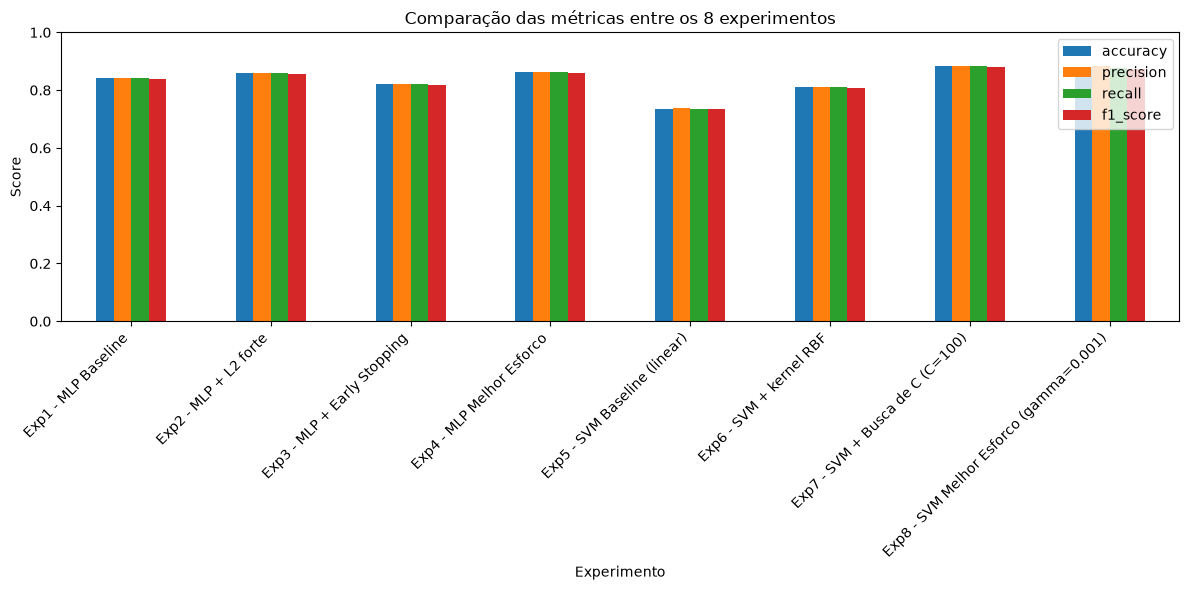


Melhor experimento (F1-Score): Exp7 - SVM + Busca de C (C=100) (F1=0.8798)


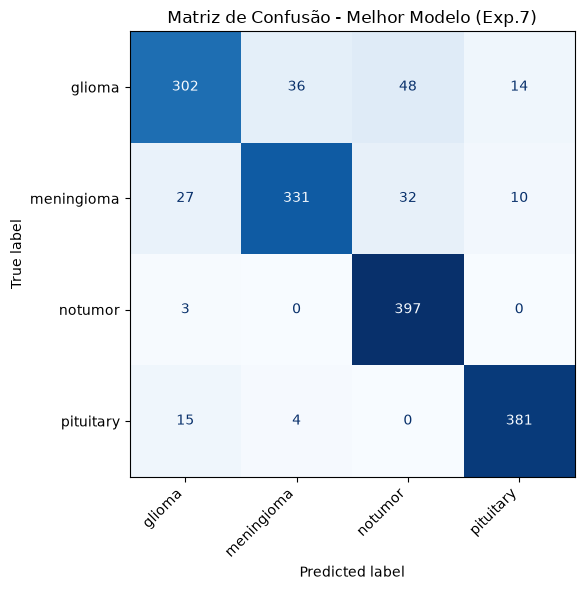

In [10]:
os.makedirs("../results/figuras", exist_ok=True)

df_final = pd.DataFrame(results)
df_final.to_csv("../results/resultados_experimentos.csv", index=False)
print(df_final)

fig, ax = plt.subplots(figsize=(12, 6))
df_final.set_index("Experimento")[["accuracy", "precision", "recall", "f1_score"]].plot(kind="bar", ax=ax)
ax.set_ylabel("Score"); ax.set_ylim(0, 1)
ax.set_title("Comparação das métricas entre os 8 experimentos")
plt.xticks(rotation=45, ha="right"); plt.tight_layout()
plt.savefig("../results/figuras/comparacao_experimentos.png", dpi=150)
plt.show()

melhor = df_final.loc[df_final["f1_score"].idxmax()]
print(f"\nMelhor experimento (F1-Score): {melhor['Experimento']} (F1={melhor['f1_score']:.4f})")

cm = confusion_matrix(y_test, svm_7.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Matriz de Confusão - Melhor Modelo (Exp.7)")
plt.xticks(rotation=45, ha="right"); plt.tight_layout()
plt.savefig("../results/figuras/matriz_confusao_melhor_modelo.png", dpi=150)
plt.show()